In [1]:
import subprocess, sys
pkgs = ['pandas','numpy','matplotlib','seaborn','scikit-learn','imbalanced-learn','python-docx']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print("All packages installed.")


All packages installed.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Voting Ensemble,0.948,0.381,0.107,0.167,0.841
1,Logistic Regression,0.731,0.130,0.787,0.223,0.839
2,AdaBoost,0.951,0.000,0.000,0.000,0.828
3,Gradient Boosting,0.948,0.250,0.027,0.048,0.824
4,Random Forest,0.949,0.000,0.000,0.000,0.801
5,Naive Bayes,0.189,0.056,0.987,0.106,0.789
6,SVM,0.759,0.119,0.613,0.200,0.776
7,KNN,0.947,0.000,0.000,0.000,0.612
8,Decision Tree,0.928,0.170,0.120,0.141,0.545


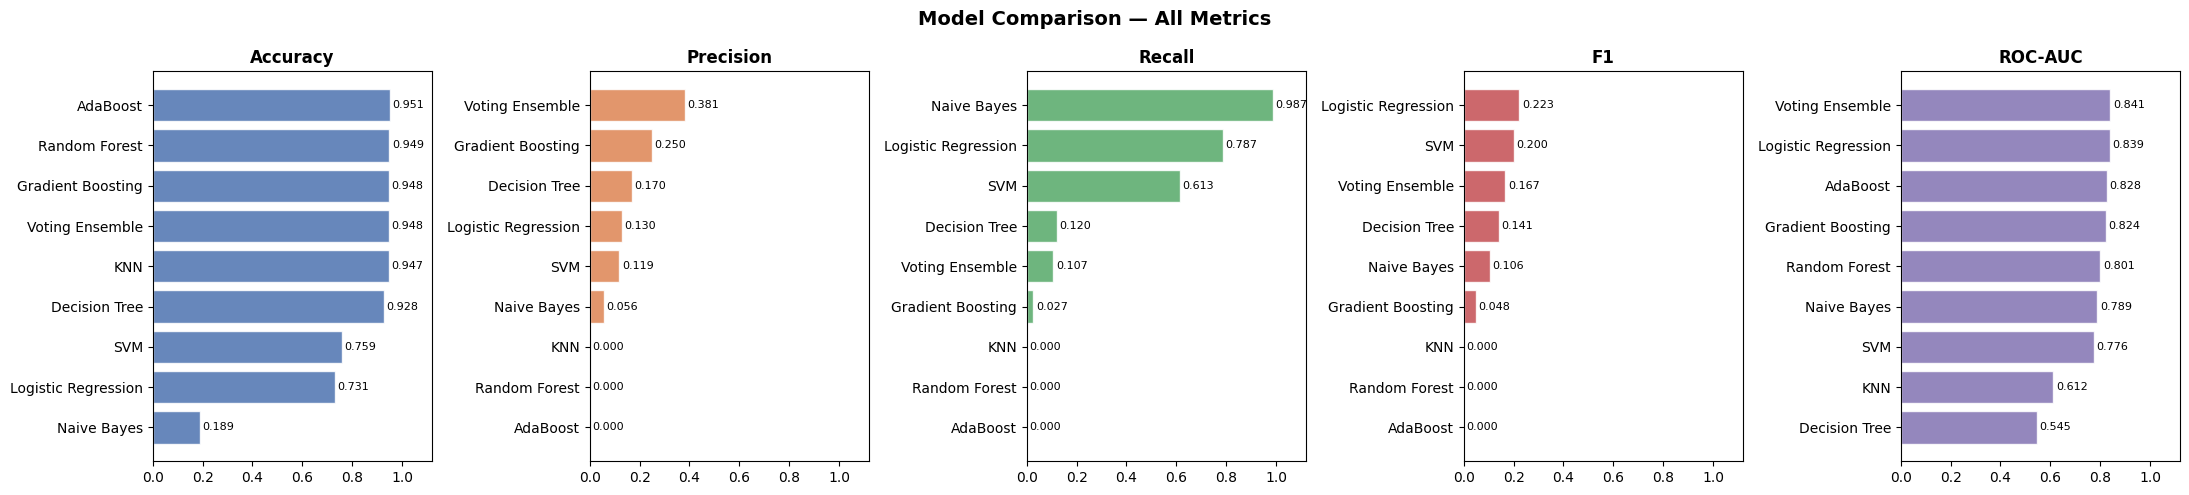

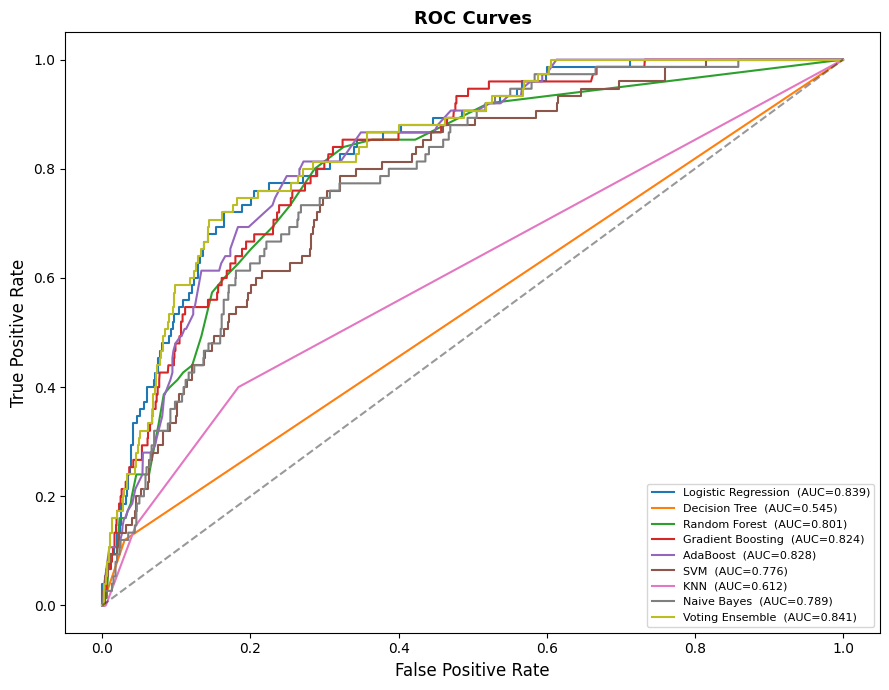

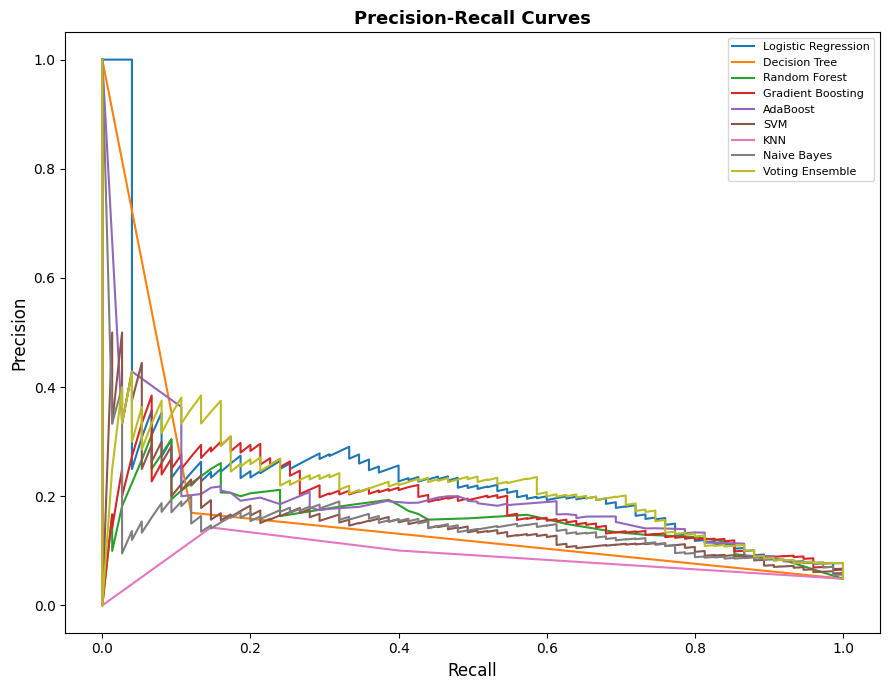

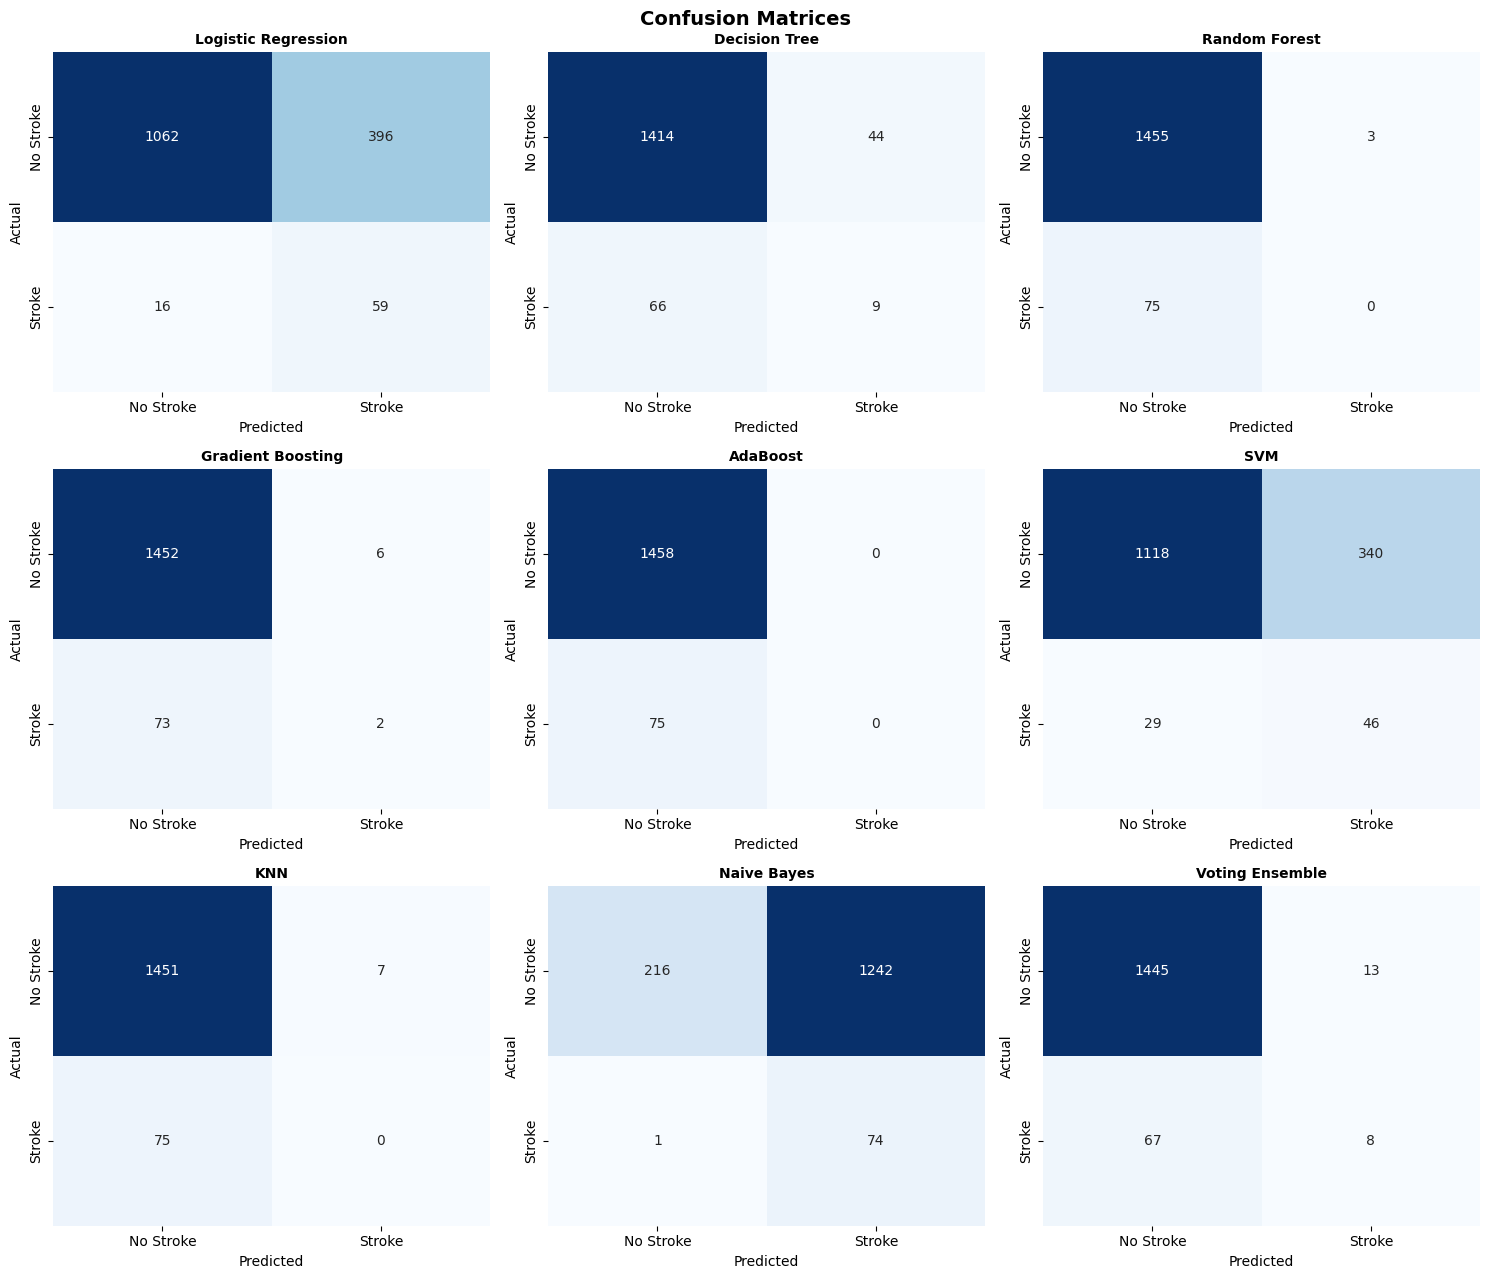

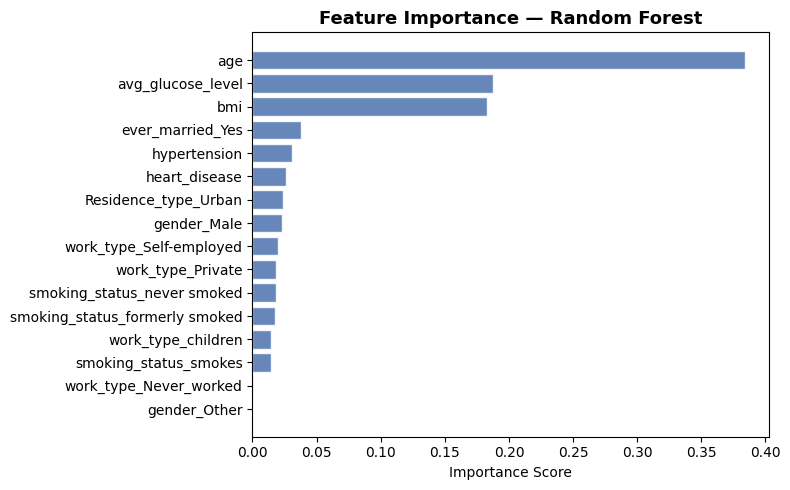


Report saved: stroke_analysis_report.docx
Best model (Voting Ensemble) saved: stroke_model.pkl
Also saved: scaler.pkl  |  feature_cols.pkl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle, os, io
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, VotingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

# ── Load & Preprocess ──────────────────────────────────────────────────────────
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.drop('id', axis=1, inplace=True)
df['bmi'] = KNNImputer(n_neighbors=5).fit_transform(df[['bmi']])
df = pd.get_dummies(df, columns=['gender','ever_married','work_type',
                                  'Residence_type','smoking_status'], drop_first=True)

X = df.drop('stroke', axis=1)
y = df['stroke']

feature_cols = X.columns.tolist()
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# ── Models ─────────────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(C=1, kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':         GaussianNB(),
    'Voting Ensemble':     VotingClassifier([
                               ('lr', LogisticRegression(max_iter=1000, class_weight='balanced')),
                               ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
                               ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
                           ], voting='soft'),
}

results, trained = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    trained[name] = model
    results.append({
        'Model':     name,
        'Accuracy':  round(model.score(X_test, y_test), 3),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'F1':        round(f1_score(y_test, y_pred), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 3),
    })

df_res = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(df_res)

# ── Helper: save fig to bytes ──────────────────────────────────────────────────
def fig_to_bytes(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    buf.seek(0)
    return buf

chart_images = {}

# ── Chart 1: Metrics Comparison ────────────────────────────────────────────────
metrics_cols = ['Accuracy','Precision','Recall','F1','ROC-AUC']
colors       = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, metric, color in zip(axes, metrics_cols, colors):
    s = df_res.sort_values(metric)
    bars = ax.barh(s['Model'], s[metric], color=color, edgecolor='white', alpha=0.85)
    ax.set_xlim(0, 1.12); ax.set_title(metric, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, s[metric]):
        ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
fig.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
chart_images['metrics'] = fig_to_bytes(fig)

# ── Chart 2: ROC Curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for name, model in trained.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=12); ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=13, fontweight='bold'); ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()
chart_images['roc'] = fig_to_bytes(fig)

# ── Chart 3: Precision-Recall Curves ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for name, model in trained.items():
    prec, rec, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:,1])
    ax.plot(rec, prec, label=name)
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold'); ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()
chart_images['pr'] = fig_to_bytes(fig)

# ── Chart 4: Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, (name, model) in zip(axes.flatten(), trained.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'], cbar=False)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
chart_images['cm'] = fig_to_bytes(fig)

# ── Chart 5: Feature Importance ────────────────────────────────────────────────
importances = trained['Random Forest'].feature_importances_
idx = np.argsort(importances)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(X.columns[idx], importances[idx], color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()
chart_images['fi'] = fig_to_bytes(fig)

# ── Build Word Document ────────────────────────────────────────────────────────
doc = Document()

# Page margins
for section in doc.sections:
    section.top_margin    = Inches(1)
    section.bottom_margin = Inches(1)
    section.left_margin   = Inches(1)
    section.right_margin  = Inches(1)

# Title
title = doc.add_heading('Stroke Risk Prediction — Model Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
title.runs[0].font.color.rgb = RGBColor(0x0F, 0x17, 0x2A)

doc.add_paragraph('Generated by Stroke Risk Prediction ML Pipeline').alignment = WD_ALIGN_PARAGRAPH.CENTER
doc.add_paragraph()

# Section 1: Metrics Summary Table
doc.add_heading('1. Model Performance Summary', level=1)
doc.add_paragraph('All models trained with class_weight=\'balanced\' to handle the 95/5 stroke imbalance.')

table = doc.add_table(rows=1, cols=len(df_res.columns))
table.style = 'Table Grid'
table.alignment = WD_TABLE_ALIGNMENT.CENTER

# Header row
hdr = table.rows[0].cells
for i, col in enumerate(df_res.columns):
    hdr[i].text = col
    hdr[i].paragraphs[0].runs[0].bold = True
    hdr[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data rows
for _, row in df_res.iterrows():
    cells = table.add_row().cells
    for i, val in enumerate(row):
        cells[i].text = str(val)
        cells[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph()

# Section 2: Classification Reports
doc.add_heading('2. Classification Reports', level=1)
for name, model in trained.items():
    doc.add_heading(name, level=2)
    report = classification_report(y_test, model.predict(X_test),
                                   target_names=['No Stroke','Stroke'], zero_division=0)
    p = doc.add_paragraph()
    p.add_run(report).font.name = 'Courier New'
    p.runs[0].font.size = Pt(9)

# Section 3: Charts
doc.add_page_break()
doc.add_heading('3. Model Comparison Charts', level=1)

doc.add_heading('Metrics Comparison', level=2)
doc.add_picture(chart_images['metrics'], width=Inches(6.5))

doc.add_heading('ROC Curves', level=2)
doc.add_picture(chart_images['roc'], width=Inches(5))

doc.add_heading('Precision-Recall Curves', level=2)
doc.add_picture(chart_images['pr'], width=Inches(5))

doc.add_heading('Confusion Matrices', level=2)
doc.add_picture(chart_images['cm'], width=Inches(6.5))

doc.add_heading('Feature Importance (Random Forest)', level=2)
doc.add_picture(chart_images['fi'], width=Inches(5))

# Save
doc.save('stroke_analysis_report.docx')
print("\nReport saved: stroke_analysis_report.docx")

# Save best model
best_name = df_res.iloc[0]['Model']
with open('stroke_model.pkl', 'wb') as f:
    pickle.dump(trained[best_name], f)
print(f"Best model ({best_name}) saved: stroke_model.pkl")
print("Also saved: scaler.pkl  |  feature_cols.pkl")
